<a href="https://colab.research.google.com/github/TanishaPodder/AIML_LAB/blob/main/AIML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BFS Traversal Order: A -> B -> C -> D -> E -> F
DFS Traversal Order: A -> B -> D -> E -> C -> F

Visualizing BFS Traversal:


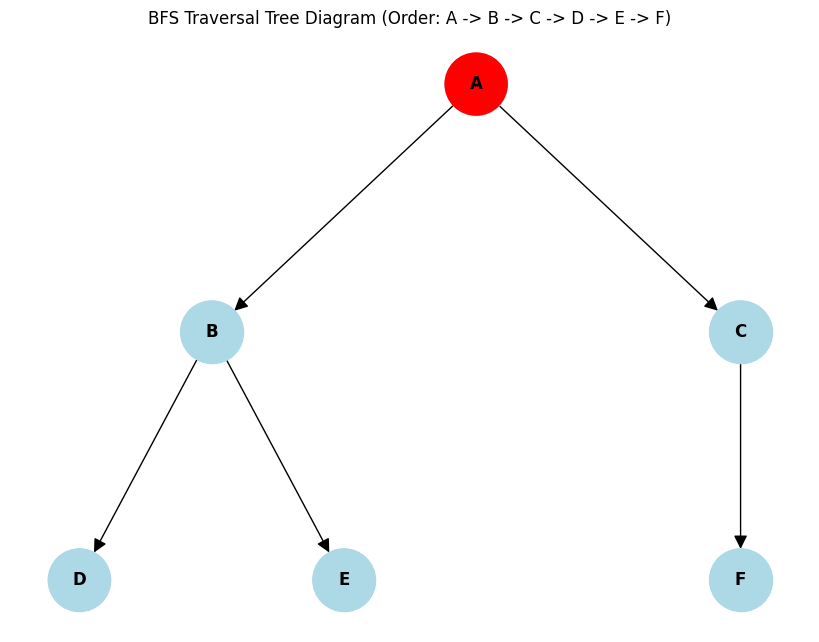


Visualizing DFS Traversal:


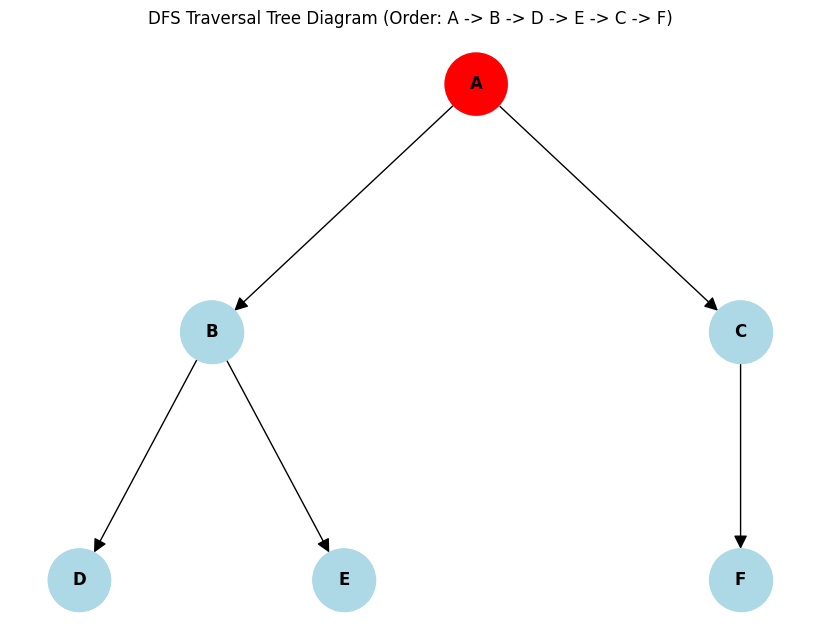

In [1]:
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# 1. Store the graph using an adjacency list (a Python dictionary)
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# 2. Perform a BFS traversal starting from node A
def bfs(graph, start_node):
    visited = set()
    queue = deque([start_node])
    bfs_order = []
    bfs_edges = []

    while queue:
        current_node = queue.popleft()
        if current_node not in visited:
            visited.add(current_node)
            bfs_order.append(current_node)
            for neighbor in graph.get(current_node, []):
                if neighbor not in visited:
                    queue.append(neighbor)
                    bfs_edges.append((current_node, neighbor))
    return bfs_order, bfs_edges

# 3. Perform a DFS traversal starting from node A
def dfs(graph, start_node):
    visited = set()
    dfs_order = []
    dfs_edges = []

    def dfs_recursive(node):
        visited.add(node)
        dfs_order.append(node)
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                dfs_edges.append((node, neighbor))
                dfs_recursive(neighbor)

    dfs_recursive(start_node)
    return dfs_order, dfs_edges

# Get traversal orders and edges
bfs_order, bfs_edges = bfs(graph, 'A')
dfs_order, dfs_edges = dfs(graph, 'A')

# 4. Print both traversal orders
print("BFS Traversal Order:", ' -> '.join(bfs_order))
print("DFS Traversal Order:", ' -> '.join(dfs_order))

# 5. Draw two separate tree diagrams
def draw_tree_diagram(edges, title, traversal_order):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    pos = {
        'A': (0, 0),
        'B': (-1, -1),
        'C': (1, -1),
        'D': (-1.5, -2),
        'E': (-0.5, -2),
        'F': (1, -2)
    }

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=12, font_weight='bold', arrowsize=20)

    # Highlight nodes in traversal order
    node_colors = ['red' if node == traversal_order[0] else 'lightblue' for node in G.nodes()]
    node_colors_ordered = []
    for node in G.nodes():
        if node in traversal_order:
            idx = traversal_order.index(node)
            # Create a gradient or specific colors for order
            # For simplicity, let's just make the first one red, others lightblue
            node_colors_ordered.append('red' if idx == 0 else 'lightblue')
        else:
            node_colors_ordered.append('lightblue') # Fallback for nodes not in traversal (shouldn't happen for these cases)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors_ordered, node_size=2000)

    # Add order labels if desired (can get cluttered)
    # labels = {node: f'{node} ({traversal_order.index(node) + 1})' for node in traversal_order}
    # nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

    plt.title(f"{title} (Order: {' -> '.join(traversal_order)})")
    plt.show()


print("\nVisualizing BFS Traversal:")
draw_tree_diagram(bfs_edges, "BFS Traversal Tree Diagram", bfs_order)

print("\nVisualizing DFS Traversal:")
draw_tree_diagram(dfs_edges, "DFS Traversal Tree Diagram", dfs_order)
